# Validación del Simulador FAR(1) — versión corregida

Notebook que verifica el módulo `simulation_pipeline_linear.py` corregido.

| # | Problema original | Corrección |
|---|---|---|
| 1 | `gaussian_filter1d` reducía `std(ε_t)` a ≈37% | Renormalización post-filtrado |
| 2 | Tendencias `linear`/`bump` dominaban el proceso para `n_curves` grande | Normalizadas por `n_curves` |
| 3 | `burn_in=50` apenas suficiente | `burn_in=100` por defecto |
| 4 | Sin validaciones de entrada | Checks de shape, tipo, `noise_std>0` |
| 5 | Sin diagnóstico integrado | `summary_stats()` y `plot_acf()` |


## 0. Imports y configuración


In [9]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, normaltest
from scipy import stats

from model_psbp_fd.pipelines import (
    FunctionalDomain,
    FARSimulator,
    gaussian_integral_kernel,
    build_integral_matrix,
)
from model_psbp_fd.functions_models import FunctionalRepresentation
from model_psbp_fd.graphics         import plot_functional_time_series

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['figure.dpi'] = 100

domain = FunctionalDomain.regular(s_min=0, s_max=1, n_points=100)
Psi    = build_integral_matrix(domain, gaussian_integral_kernel,
                               bandwidth=0.05, decay=0.6)
print('Dominio:', domain)


Dominio: FunctionalDomain(n_points=100, range=[0.00, 1.00])


## 1. Visualizar Tendencias

Para cada una de las cuatro tendencias disponibles (`zero`, `linear`,
`sinusoidal`, `bump`) se simulan 100 curvas FAR(1) y se visualizan
**reconstruidas desde coeficientes de base B-spline**, no en escala bruta.

**Por qué reconstruir desde la base?**  
Las curvas brutas $X_t(s)$ contienen ruido punto a punto que puede
enmascarar la estructura funcional real.  Al proyectar sobre una base
($\Theta_t = \text{FR.transform}(X_t)$) y reconstruir
($\hat X_t = \Theta_t \cdot \Phi$) se obtiene la versión suavizada que
el pipeline PSBP-FD usa internamente.  Visualizar $\hat X_t$ es
equivalente a ver el comportamiento en el espacio de coeficientes,
que es donde opera el modelo.


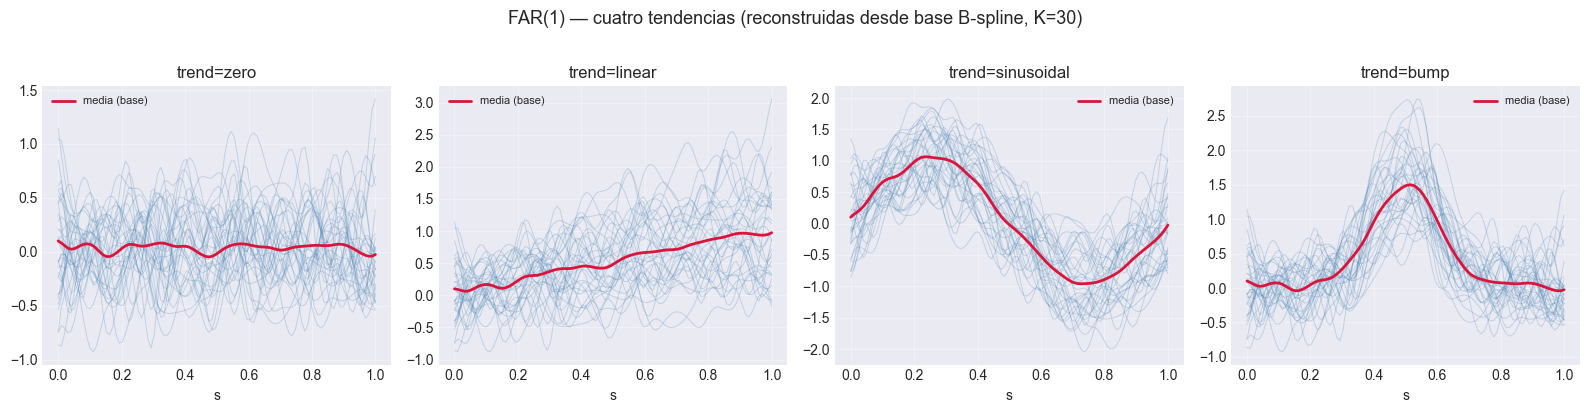

In [6]:
trends  = ['zero', 'linear', 'sinusoidal', 'bump']
n_basis = 30   # base B-spline para la representación funcional

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, trend_name in zip(axes, trends):
    # 1. Simular
    sim = FARSimulator(
        domain=domain, n_curves=100, Psi=Psi,
        trend=trend_name, noise_std=0.3,
        noise_type='smooth', burn_in=100, random_state=42,
    )
    X = sim.simulate()

    # 2. Representación funcional → coeficientes → reconstrucción
    fr    = FunctionalRepresentation(method='bspline', n_basis=n_basis)
    THETA = fr.fit_transform(X, domain.grid)   # (T, K)
    X_hat = fr.reconstruct(THETA)              # (T, G) curvas suavizadas

    # 3. Plot de curvas reconstruidas
    for t in range(0, 100, 3):
        ax.plot(domain.grid, X_hat[t], alpha=0.25, lw=0.7, color='steelblue')
    ax.plot(domain.grid, X_hat.mean(axis=0),
            color='crimson', lw=2, label='media (base)')
    ax.set_title(f'trend={trend_name}')
    ax.set_xlabel('s')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle(
    f'FAR(1) — cuatro tendencias (reconstruidas desde base B-spline, K={n_basis})',
    fontsize=13, y=1.02,
)
plt.tight_layout()
plt.show()


## 2. Estabilidad del operador Ψ

El proceso FAR(1) es **estacionario** si y solo si el operador integral Ψ
satisface $\|\Psi\|_{op} < 1$.  En la discretización matricial esto se
traduce en que todos los valores propios de la matriz Ψ tengan módulo
menor a 1: $|\lambda|_{\max} < 1$.

**Por qué importa?**

| Condición | Comportamiento del proceso |
|---|---|
| $|\lambda|_{\max} < 1$ | Estacionario: la varianza no crece con $t$ |
| $|\lambda|_{\max} = 1$ | Raíz unitaria: paseo aleatorio funcional |
| $|\lambda|_{\max} > 1$ | Explosivo: las curvas divergen con $t$ |

La tabla a continuación explora distintas combinaciones de `bandwidth`
(anchura del kernel gaussiano) y `decay` (escala del operador).  Se
busca la región del espacio de parámetros donde el proceso sigue siendo
estacionario, que es el régimen válido para simular datos funcionales
representativos de series reales.

> **Regla práctica**: `decay` alto + `bandwidth` angosto tiende a
> acercar $|\lambda|_{\max}$ a 1.  El valor `decay=0.6, bandwidth=0.05`
> usado en el resto del notebook da $|\lambda|_{\max} \approx 0.55$,
> garantizando estacionariedad con margen.


In [7]:
bandwidths = [0.02, 0.05, 0.1, 0.15]
decays     = [0.5, 0.6, 0.7, 0.9]

print(f"{'bandwidth':>12} {'decay':>8} {'|lam|_max':>12} {'estable':>8}")
print('-' * 48)
for bw in bandwidths:
    for dc in decays:
        P = build_integral_matrix(domain, gaussian_integral_kernel,
                                  bandwidth=bw, decay=dc)
        lmax = np.max(np.abs(np.linalg.eigvals(P)))
        ok = 'OK' if lmax < 1 else 'INESTABLE'
        print(f'{bw:>12.3f} {dc:>8.2f} {lmax:>12.4f} {ok:>8}')


   bandwidth    decay    |lam|_max  estable
------------------------------------------------
       0.020     0.50       0.4991       OK
       0.020     0.60       0.5989       OK
       0.020     0.70       0.6987       OK
       0.020     0.90       0.8983       OK
       0.050     0.50       0.4946       OK
       0.050     0.60       0.5936       OK
       0.050     0.70       0.6925       OK
       0.050     0.90       0.8903       OK
       0.100     0.50       0.4809       OK
       0.100     0.60       0.5771       OK
       0.100     0.70       0.6733       OK
       0.100     0.90       0.8657       OK
       0.150     0.50       0.4620       OK
       0.150     0.60       0.5544       OK
       0.150     0.70       0.6468       OK
       0.150     0.90       0.8316       OK


## 3. Visualizar la serie

In [8]:
# 1. Configurar dominio y simulador
domain = FunctionalDomain.regular(n_points=100)
Psi    = build_integral_matrix(domain, gaussian_integral_kernel,
                               bandwidth=0.05, decay=0.9)

sim = FARSimulator(
    domain       = domain,
    n_curves     = 50,
    Psi          = Psi,
    trend        = 'linear',
    noise_std    = 1,
    noise_type   = 'smooth',
    burn_in      = 100,
    random_state = 42,
)

X = sim.simulate()
print(f'Datos generados : {X.shape}  →  T={X.shape[0]} curvas,  G={X.shape[1]} puntos')
print(f'Dominio s       : [{domain.grid.min():.2f}, {domain.grid.max():.2f}]')

# 2. Representación funcional → coeficientes
fr    = FunctionalRepresentation(method='bspline', n_basis=15)
THETA = fr.fit_transform(X, domain.grid)
print(f'Coeficientes THETA : {THETA.shape}   (T={THETA.shape[0]}, K={THETA.shape[1]})')


Datos generados : (50, 100)  →  T=50 curvas,  G=100 puntos
Dominio s       : [0.00, 1.00]
Coeficientes THETA : (50, 15)   (T=50, K=15)


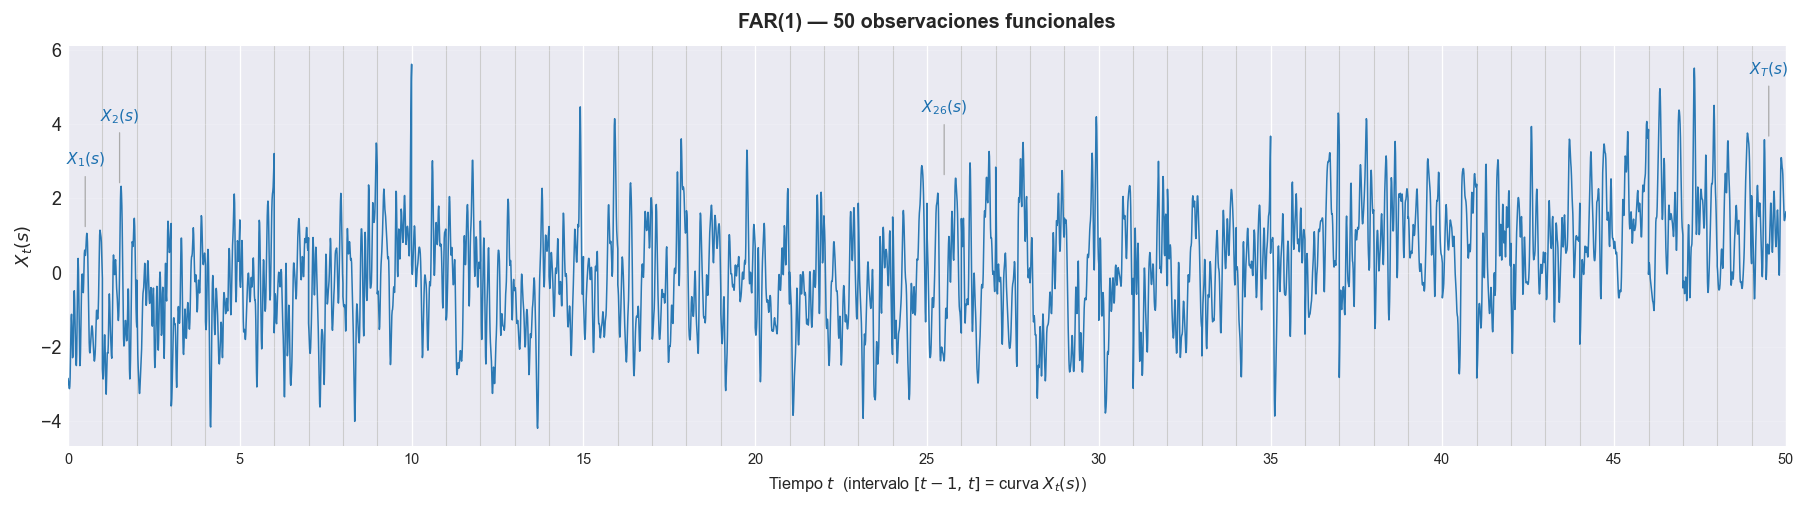

In [11]:
fig = plot_functional_time_series(
    X, domain.grid,
    highlight_idx  = [0, 1, sim.n_curves // 2, sim.n_curves - 1],
    title          = f"FAR(1) — {sim.n_curves} observaciones funcionales",
)
plt.show()


## Mas ejemplos de uso

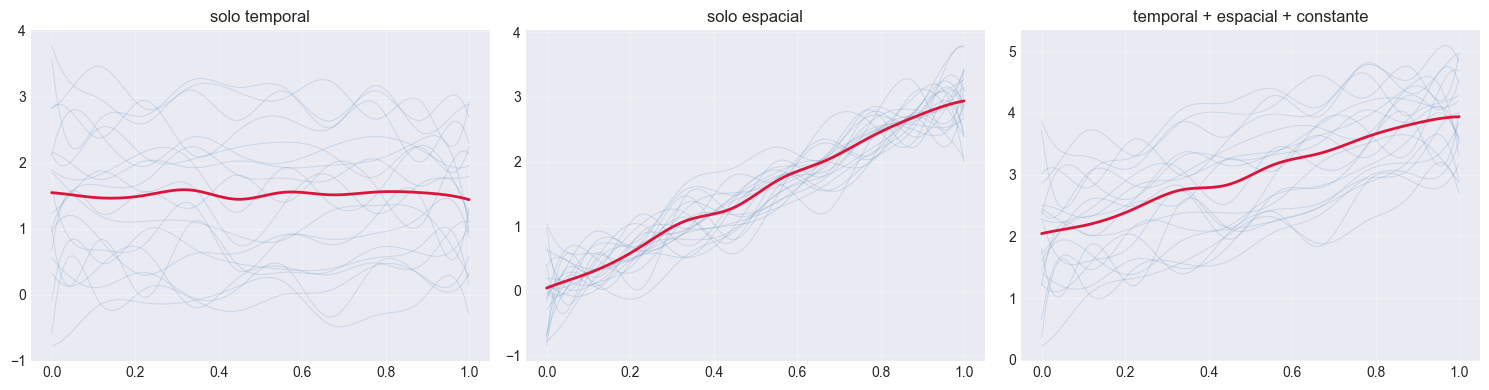

In [12]:
configs = [
    {"temporal_slope": 3.0, "spatial_slope": 0.0, "intercept": 0.0},  # solo crece en t
    {"temporal_slope": 0.0, "spatial_slope": 3.0, "intercept": 0.0},  # solo crece en s
    {"temporal_slope": 2.0, "spatial_slope": 2.0, "intercept": 1.0},  # ambos + constante
]
labels = ["solo temporal", "solo espacial", "temporal + espacial + constante"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, params, label in zip(axes, configs, labels):
    sim = FARSimulator(domain=domain, n_curves=80, Psi=Psi,
                       trend="linear", trend_params=params,
                       noise_std=0.3, random_state=42)
    X = sim.simulate()
    fr = FunctionalRepresentation(method="bspline", n_basis=12)
    X_hat = fr.reconstruct(fr.fit_transform(X, domain.grid))
    for t in range(0, 80, 4):
        ax.plot(domain.grid, X_hat[t], alpha=0.2, lw=0.7, color="steelblue")
    ax.plot(domain.grid, X_hat.mean(axis=0), color="crimson", lw=2)
    ax.set_title(label); ax.grid(True, alpha=0.3)
plt.tight_layout()